# Multiple Regression before selection

#### Data Import

In [1]:
import intake
import numpy as np
import matplotlib.pylab as plt
import xarray as xr
import matplotlib.colors as colors
from shapely.geometry import Polygon, Point, box
from shapely import contains_xy
import time
from scipy.stats import linregress
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [2]:
#import data 
edso1_clt_ac = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_clt_ac.nc")
edso1_clt_c = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_clt_c.nc")

In [3]:
edso1_clt = xr.concat([edso1_clt_ac, edso1_clt_c], dim="obs")
edso1_clt = edso1_clt.assign_coords(number=("obs", np.arange(edso1_clt.sizes["obs"])))

In [4]:
#import data (generated in this notebook)
edso1_dn23_hfls_ac = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_hfls_ac.nc")
edso1_dn23_hfls_c = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_hfls_c.nc")

FileNotFoundError: [Errno 2] No such file or directory: b'/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_hfls_ac.nc'

In [ ]:
edso1_hfls = xr.concat([edso1_dn23_hfls_ac, edso1_dn23_hfls_c], dim="obs")
edso1_hfls = edso1_hfls.assign_coords(number=("obs", np.arange(edso1_hfls.sizes["obs"])))

In [ ]:
#import data (generated in this notebook)
edso1_dn23_hfss_ac = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_hfss_ac.nc")
edso1_dn23_hfss_c = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_hfss_c.nc")

In [ ]:
edso1_hfss = xr.concat([edso1_dn23_hfss_ac, edso1_dn23_hfss_c], dim="obs")
edso1_hfss = edso1_hfss.assign_coords(number=("obs", np.arange(edso1_hfss.sizes["obs"])))

In [ ]:
#import data 
edso1_dn23_sfcwind_ac = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_sfcwind_ac.nc")
edso1_dn23_sfcwind_c = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_sfcwind_c.nc")

In [ ]:
edso1_sfcwind = xr.concat([edso1_dn23_sfcwind_ac, edso1_dn23_sfcwind_c], dim="obs")
edso1_sfcwind = edso1_sfcwind.assign_coords(number=("obs", np.arange(edso1_sfcwind.sizes["obs"])))

In [10]:
edso1_sfcwind

<xarray.Dataset>
Dimensions:                        (obs: 3402712, NbSample: 50)
Coordinates:
  * obs                            (obs) float64 1.0 2.0 ... 1.95e+06 1.95e+06
    number                         (obs) int64 0 1 2 ... 3402709 3402710 3402711
Dimensions without coordinates: NbSample
Data variables: (12/41)
    amplitude                      (obs) float64 0.008 0.01 ... -0.1395 -0.1393
    cost_association               (obs) float32 0.2152 0.2833 ... 9.969e+36
    effective_area                 (obs) float32 5.428e+08 ... 1.738e+10
    effective_contour_height       (obs) float32 -0.048 -0.048 ... -0.06 -0.06
    effective_contour_latitude     (obs, NbSample) float64 -75.94 ... -61.86
    effective_contour_longitude    (obs, NbSample) float64 203.5 203.6 ... 237.2
    ...                             ...
    dif_sfcwind                    (obs) float64 -0.6381 0.0295 ... 0.09526
    sst_mean_ed                    (obs) float64 2.889 3.52 ... 5.442 5.523
    sst_npoints_ed                 (obs) float64 4.0 4.0 4.0 ... 51.0 48.0 48.0
    sst_mean_donut                 (obs) float64 3.223 3.798 ... 5.643 5.634
    sst_npoints_donut              (obs) float64 16.0 17.0 20.0 ... 238.0 254.0
    dif_sst                        (obs) float64 -0.3339 -0.2778 ... -0.1106
Attributes: (12/13)
    track_extra_variables:     lat_max,lon_max
    track_array_variables:     50
    array_variables:           contour_lat_e,contour_lon_e,contour_lat_s,cont...
    title:                     Anticyclonic
    Metadata_Conventions:      Unidata Dataset Discovery v1.0
    comment:                   Surface product; mesoscale eddies
    ...                        ...
    framework_version:         0+unknown
    standard_name_vocabulary:  NetCDF Climate and Forecast (CF) Metadata Conv...
    date_created:              2025-09-05T07:58:08Z
    time_coverage_duration:    P8034D
    time_coverage_start:       1993-01-01T00:00:00Z
    time_coverage_end:         2014-12-31T00:00:00Z

In [31]:
edso1_clt

<xarray.Dataset>
Dimensions:                        (obs: 3402712, NbSample: 50)
Coordinates:
  * obs                            (obs) float64 1.0 2.0 ... 1.95e+06 1.95e+06
    number                         (obs) int64 0 1 2 ... 3402709 3402710 3402711
Dimensions without coordinates: NbSample
Data variables: (12/41)
    amplitude                      (obs) float64 0.008 0.01 ... -0.1395 -0.1393
    cost_association               (obs) float32 0.2152 0.2833 ... 9.969e+36
    effective_area                 (obs) float32 5.428e+08 ... 1.738e+10
    effective_contour_height       (obs) float32 -0.048 -0.048 ... -0.06 -0.06
    effective_contour_latitude     (obs, NbSample) float64 -75.94 ... -61.86
    effective_contour_longitude    (obs, NbSample) float64 203.5 203.6 ... 237.2
    ...                             ...
    dif_clt                        (obs) float64 0.005324 0.00559 ... 0.004964
    sst_mean_ed                    (obs) float64 2.889 3.52 ... 5.442 5.523
    sst_npoints_ed                 (obs) float64 4.0 4.0 4.0 ... 51.0 48.0 48.0
    sst_mean_donut                 (obs) float64 3.223 3.798 ... 5.643 5.634
    sst_npoints_donut              (obs) float64 16.0 17.0 20.0 ... 238.0 254.0
    dif_sst                        (obs) float64 -0.3339 -0.2778 ... -0.1106
Attributes: (12/13)
    track_extra_variables:     lat_max,lon_max
    track_array_variables:     50
    array_variables:           contour_lat_e,contour_lon_e,contour_lat_s,cont...
    title:                     Anticyclonic
    Metadata_Conventions:      Unidata Dataset Discovery v1.0
    comment:                   Surface product; mesoscale eddies
    ...                        ...
    framework_version:         0+unknown
    standard_name_vocabulary:  NetCDF Climate and Forecast (CF) Metadata Conv...
    date_created:              2025-09-05T07:58:08Z
    time_coverage_duration:    P8034D
    time_coverage_start:       1993-01-01T00:00:00Z
    time_coverage_end:         2014-12-31T00:00:00Z

#### DOF Method

#### multiple regression OLS

In [41]:
#Convert xarray → pandas
ds_single = edso1_hfls.isel(NbSample=0)
df_pd = ds_single.to_dataframe().reset_index()

df_pd["amplitude"] = df_pd["amplitude"].abs()

#Standardize predictors
scaler = StandardScaler()
X = df_pd[["amplitude", "effective_radius", "effective_contour_shape_error"]]
X_std = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_std = X_std.rename(columns={
    "effective_contour_shape_error": "shape error",
    "amplitude": "amplitude",
    "effective_radius": "radius",
    "speed_average": "average speed"
})


# 3. Standardize y
y = df_pd["dif_hfls"].to_numpy().reshape(-1, 1)
y_std = StandardScaler().fit_transform(y).ravel()

# 4. Add constant
X_std = sm.add_constant(X_std)

# 5. Fit OLS
ols = sm.OLS(y_std, X_std).fit()

print(ols.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     953.7
Date:                Sun, 08 Feb 2026   Prob (F-statistic):               0.00
Time:                        14:06:34   Log-Likelihood:            -4.8268e+06
No. Observations:             3402712   AIC:                         9.654e+06
Df Residuals:                 3402708   BIC:                         9.654e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -4.499e-16      0.001   -8.3e-13      

In [35]:
import numpy as np
from scipy import stats

def adjust_inference_multivariate(model, n_eff, alpha=0.05):
    """
    Adjust t-values, p-values, and confidence intervals for an OLS model
    using an effective sample size n_eff.

    Parameters
    ----------
    model : statsmodels OLS results
        Fitted OLS model.
    n_eff : float
        Effective sample size.
    alpha : float
        Confidence level for CI.

    Returns
    -------
    dict
        Dictionary with adjusted SE, t, p, CI for all coefficients.
    """

    params = model.params
    se_orig = model.bse
    n = model.nobs
    k = len(params)  # number of coefficients including constant

    # Adjusted standard errors
    se_adj = se_orig * np.sqrt(n / n_eff)

    # Adjusted t-values
    t_adj = params / se_adj

    # Effective degrees of freedom
    df_eff = n_eff - k

    # Adjusted p-values
    p_adj = 2 * (1 - stats.t.cdf(np.abs(t_adj), df=df_eff))

    # Adjusted confidence intervals
    tcrit = stats.t.ppf(1 - alpha/2, df=df_eff)
    ci_low = params - tcrit * se_adj
    ci_high = params + tcrit * se_adj

    return {
        "beta": params,
        "se_adjusted": se_adj,
        "t_adjusted": t_adj,
        "p_adjusted": p_adj,
        "ci_adjusted": np.column_stack([ci_low, ci_high]),
        "df_eff": df_eff
    }


In [36]:
n = len(df_pd)
n_eff = n / 7   # your decorrelation timescale

adj_clt = adjust_inference_multivariate(ols, n_eff)
X_std_clt = X_std
print("beta", adj_clt["beta"])
print("se", adj_clt["se_adjusted"])
print("t", adj_clt["t_adjusted"])
print("p", adj_clt["p_adjusted"])
print("ci", adj_clt["ci_adjusted"])


beta const         -1.722289e-15
amplitude      2.044757e-03
radius         5.543729e-03
shape error    4.316967e-03
dtype: float64
se const          0.001434
amplitude      0.001827
radius         0.001856
shape error    0.001509
dtype: float64
t const         -1.200841e-12
amplitude      1.118939e+00
radius         2.987250e+00
shape error    2.861592e+00
dtype: float64
p [1.         0.2631666  0.00281513 0.00421536]
ci [[-0.00281106  0.00281106]
 [-0.0015369   0.00562642]
 [ 0.00190643  0.00918103]
 [ 0.00136018  0.00727375]]


In [38]:
adj_sfcwind = adjust_inference_multivariate(ols, n_eff)
X_std_sfcwind = X_std
print("beta", adj_sfcwind["beta"])
print("se", adj_sfcwind["se_adjusted"])
print("t", adj_sfcwind["t_adjusted"])
print("p", adj_sfcwind["p_adjusted"])
print("ci", adj_sfcwind["ci_adjusted"])


beta const          1.455406e-16
amplitude      2.298531e-02
radius        -2.992545e-02
shape error   -1.625100e-04
dtype: float64
se const          0.001434
amplitude      0.001827
radius         0.001855
shape error    0.001508
dtype: float64
t const          1.015037e-13
amplitude      1.258154e+01
radius        -1.612979e+01
shape error   -1.077525e-01
dtype: float64
p [1.         0.         0.         0.91419204]
ci [[-0.00281029  0.00281029]
 [ 0.01940463  0.026566  ]
 [-0.03356176 -0.02628913]
 [-0.00311849  0.00279347]]


In [40]:
adj_hfss = adjust_inference_multivariate(ols, n_eff)
X_std_hfss = X_std
print("beta", adj_hfss["beta"])
print("se", adj_hfss["se_adjusted"])
print("t", adj_hfss["t_adjusted"])
print("p", adj_hfss["p_adjusted"])
print("ci", adj_hfss["ci_adjusted"])


beta const          1.886702e-15
amplitude     -3.099153e-02
radius         7.076264e-03
shape error    9.967324e-03
dtype: float64
se const          0.001434
amplitude      0.001827
radius         0.001855
shape error    0.001508
dtype: float64
t const          1.316039e-12
amplitude     -1.696657e+01
radius         3.814695e+00
shape error    6.609884e+00
dtype: float64
p [1.00000000e+00 0.00000000e+00 1.36368148e-04 3.85016463e-11]
ci [[-0.00280985  0.00280985]
 [-0.03457165 -0.0274114 ]
 [ 0.00344052  0.01071201]
 [ 0.0070118   0.01292284]]


In [42]:
adj_hfls = adjust_inference_multivariate(ols, n_eff)
X_std_hfls = X_std
print("beta", adj_hfls["beta"])
print("se", adj_hfls["se_adjusted"])
print("t", adj_hfls["t_adjusted"])
print("p", adj_hfls["p_adjusted"])
print("ci", adj_hfls["ci_adjusted"])


beta const         -4.499303e-16
amplitude     -2.977912e-02
radius         1.176745e-02
shape error    1.100089e-02
dtype: float64
se const          0.001434
amplitude      0.001827
radius         0.001855
shape error    0.001508
dtype: float64
t const         -3.138276e-13
amplitude     -1.630208e+01
radius         6.343342e+00
shape error    7.294962e+00
dtype: float64
p [1.00000000e+00 0.00000000e+00 2.25029995e-10 2.99316127e-13]
ci [[-0.00280998  0.00280998]
 [-0.03335941 -0.02619883]
 [ 0.00813154  0.01540336]
 [ 0.00804523  0.01395654]]


In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

def compute_vif(X):
    vif_data = pd.DataFrame()
    vif_data["variable"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                       for i in range(X.shape[1])]
    return vif_data


In [14]:
vif_table = compute_vif(X_std_clt)
print(vif_table)


      variable       VIF
0        const  1.000000
1    amplitude  1.623414
2       radius  1.674249
3  shape error  1.106371


/tmp/ipykernel_1423674/3887866082.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0,0].set_xticklabels(coef_clt.index, rotation=0, ha="center", fontsize = 14)
/tmp/ipykernel_1423674/3887866082.py:34: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0,1].set_xticklabels(coef_wind.index, rotation=0, ha="center", fontsize = 14)
/tmp/ipykernel_1423674/3887866082.py:48: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[1,0].set_xticklabels(coef_hfss.index, rotation=0, ha="center", fontsize = 14)
/tmp/ipykernel_1423674/3887866082.py:61: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[1,1].set_xticklabels(coef_hfls.index, rotation=0, ha="center", fontsize = 14)


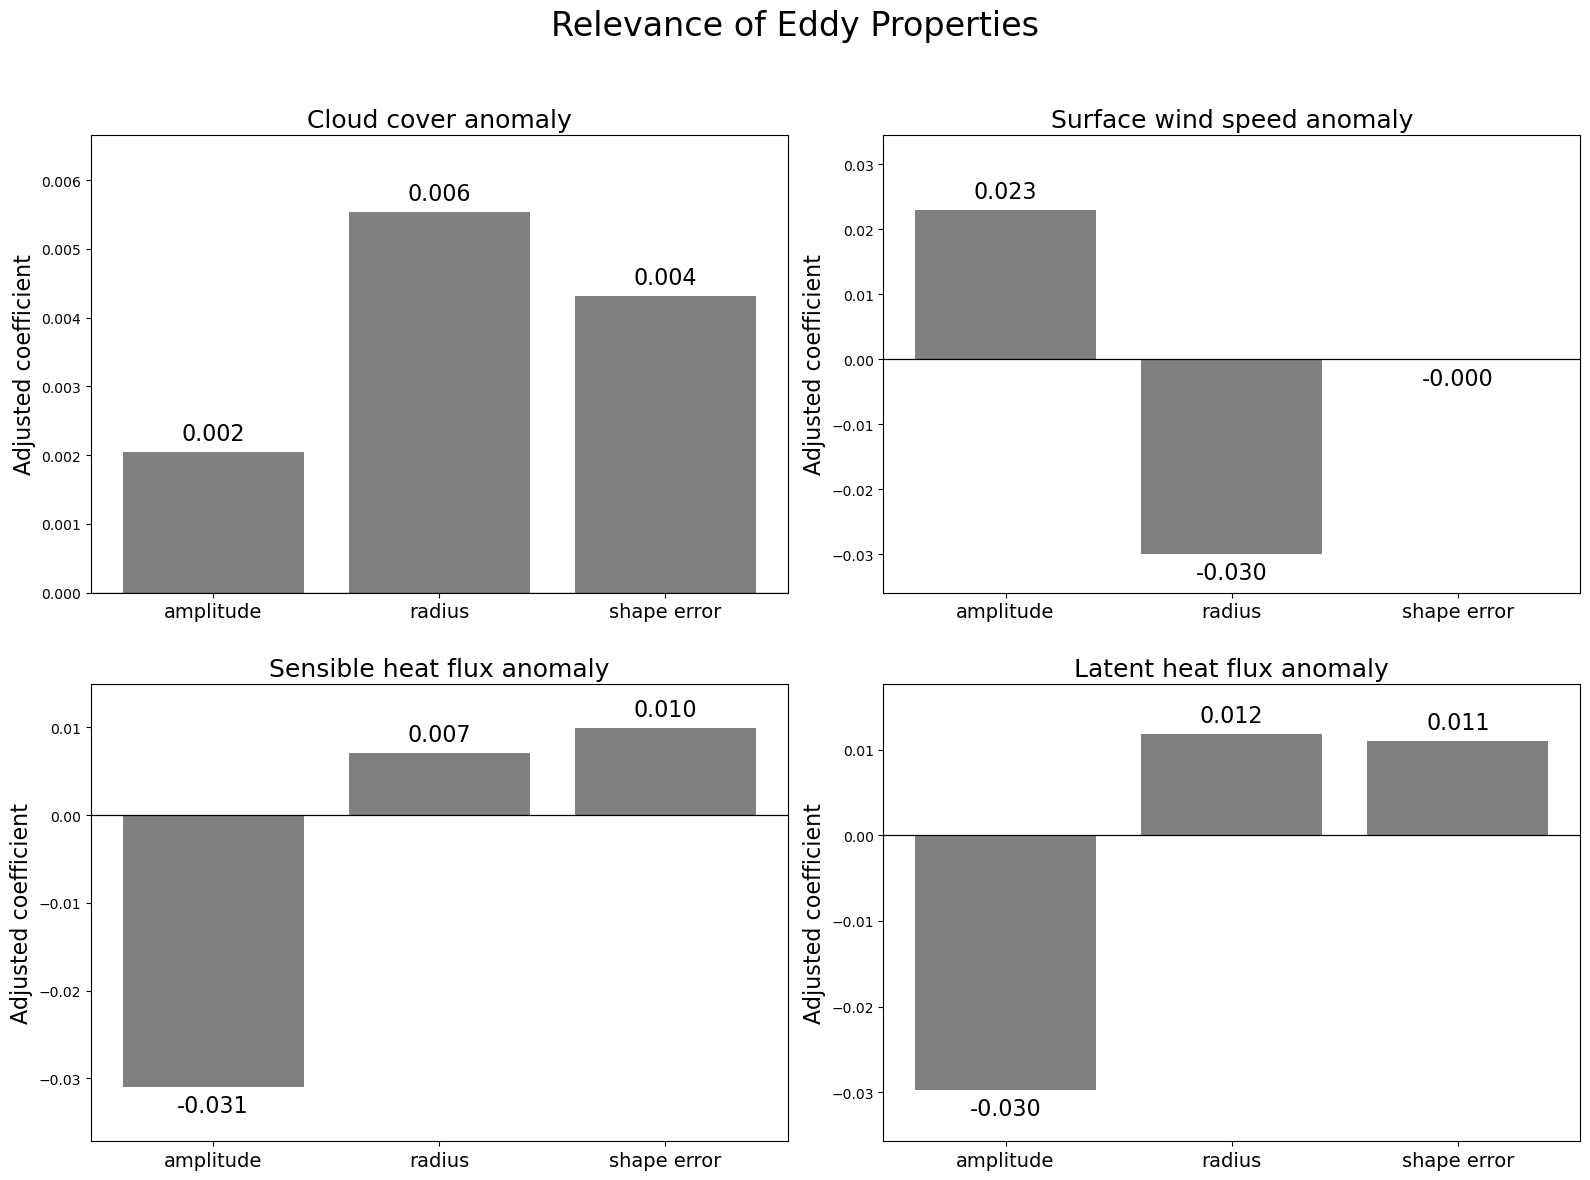

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16,12))

# Overall title
fig.suptitle("Relevance of Eddy Properties", fontsize=24, y=0.98)

bar_color = "grey"

#cloud cover
coef_clt = pd.Series(adj_clt["beta"], index=X_std_clt.columns).drop("const", errors="ignore")

bars = axes[0,0].bar(coef_clt.index, coef_clt.values, color=bar_color)
axes[0,0].bar_label(bars, fmt="%.3f", padding=5, fontsize = 16)
axes[0,0].set_title("Cloud cover anomaly",  fontsize = 18)
axes[0,0].set_ylabel("Adjusted coefficient",  fontsize = 16)
axes[0,0].set_xticklabels(coef_clt.index, rotation=0, ha="center", fontsize = 14)
axes[0,0].axhline(0, color='black', linewidth=0.9)
axes[0,0].set_ylim(0, coef_clt.max() * 1.2)


#surface wind speed
coef_wind = pd.Series(adj_sfcwind["beta"], index=X_std_sfcwind.columns).drop("const", errors="ignore")

bars = axes[0,1].bar(coef_wind.index, coef_wind.values, color=bar_color)
axes[0,1].bar_label(bars, fmt="%.3f", padding=5, fontsize = 16)
axes[0,1].set_title("Surface wind speed anomaly",  fontsize = 18)
axes[0,1].set_ylabel("Adjusted coefficient",  fontsize = 16)
axes[0,1].set_xticklabels(coef_wind.index, rotation=0, ha="center", fontsize = 14)
axes[0,1].axhline(0, color='black', linewidth=0.9)
axes[0,1].set_ylim(coef_wind.min() * 1.2, coef_wind.max()*1.5)


#shf
coef_hfss = pd.Series(adj_hfss["beta"], index=X_std_hfss.columns).drop("const", errors="ignore")

bars = axes[1,0].bar(coef_hfss.index, coef_hfss.values, color=bar_color)
axes[1,0].bar_label(bars, fmt="%.3f", padding=5, fontsize = 16)
axes[1,0].set_title("Sensible heat flux anomaly",  fontsize = 18)
axes[1,0].set_ylabel("Adjusted coefficient",  fontsize = 16)
axes[1,0].set_xticklabels(coef_hfss.index, rotation=0, ha="center", fontsize = 14)
axes[1,0].axhline(0, color='black', linewidth=0.9)
axes[1,0].set_ylim(coef_hfss.min() * 1.2, coef_hfss.max()*1.5)

#lhf
coef_hfls = pd.Series(adj_hfls["beta"], index=X_std_hfls.columns).drop("const", errors="ignore")

bars = axes[1,1].bar(coef_hfls.index, coef_hfls.values, color=bar_color)
axes[1,1].bar_label(bars, fmt="%.3f", padding=5, fontsize = 16)
axes[1,1].set_title("Latent heat flux anomaly", fontsize = 18)
axes[1,1].set_ylabel("Adjusted coefficient",  fontsize = 16)
axes[1,1].set_xticklabels(coef_hfls.index, rotation=0, ha="center", fontsize = 14)
axes[1,1].axhline(0, color='black', linewidth=0.9)
axes[1,1].set_ylim(coef_hfls.min() * 1.2, coef_hfls.max() * 1.5)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(hspace=0.2)
plt.savefig("eddy_prop_relevance_before_2.pdf")
plt.show()


In [5]:
def monte_carlo_weekly_multireg(ds, predictors, response='dif_clt', n_iter=100, seed=None, min_points=3):
    rng = np.random.default_rng(seed)
    
    time_vals = ds['time'].values
    time_min = time_vals.min()
    week_bin = ((time_vals - time_min) / np.timedelta64(1, 'D') // 7).astype(int)
    unique_weeks = np.unique(week_bin)
    
    coef_list = []
    n_skipped = 0

    for _ in range(n_iter):
        selected_indices = []

        for w in unique_weeks:
            indices_in_bin = np.where(week_bin == w)[0]
            if len(indices_in_bin) == 0:
                continue
            selected_indices.append(rng.choice(indices_in_bin))
        
        if len(selected_indices) < min_points:
            n_skipped += 1
            continue
        
        ds_sample = ds.isel(obs=selected_indices)
        
        # build predictors matrix
        X = np.column_stack([ds_sample[p].values for p in predictors])
        y = ds_sample[response].values
        
        # remove NaNs
        mask = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
        X = X[mask]
        y = y[mask]
        
        if len(y) < min_points or np.std(y) == 0:
            n_skipped += 1
            continue
        
        # standardize predictors
        X_std = StandardScaler().fit_transform(X)
        X_std = sm.add_constant(X_std)  # add intercept
        
        # fit multiple regression
        model = sm.OLS(y, X_std).fit()
        
        # store coefficients (exclude intercept)
        coef_list.append(model.params[1:])  # first param is intercept
    
    coef_array = np.array(coef_list)
    
    # mean and std over MC iterations
    coef_mean = np.nanmean(coef_array, axis=0)
    coef_std = np.nanstd(coef_array, axis=0)
    
    return coef_mean, coef_std, coef_array


In [10]:
predictors = ['amplitude', 'effective_radius', 'speed_average', 'dif_sst']
coef_mean, coef_std, coef_all = monte_carlo_weekly_multireg(edso1_dn23_clt_q75_e20, predictors, "dif_clt", n_iter=1000)
coef_mean_hfls, coef_std_hfls, coef_all_hfls = monte_carlo_weekly_multireg(edso1_dn23_hfls_q75_e20, predictors, "dif_hfls", n_iter=1000)
coef_mean_hfss, coef_std_hfss, coef_all_hfss = monte_carlo_weekly_multireg(edso1_dn23_hfss_q75_e20, predictors, "dif_hfss", n_iter=1000)
coef_mean_sfcwind, coef_std_sfcwind, coef_all_sfcwind = monte_carlo_weekly_multireg(edso1_dn23_sfcwind_q75_e20, predictors, "dif_sfcwind", n_iter=1000)

for p, m, s in zip(predictors, coef_mean, coef_std):
    print(f"{p}: mean={m:.3f}, std={s:.3f}")
    
for p, m, s in zip(predictors, coef_mean_hfls, coef_std_hfls):
    print(f"{p}: mean={m:.3f}, std={s:.3f}")

for p, m, s in zip(predictors, coef_mean_hfss, coef_std_hfss):
    print(f"{p}: mean={m:.3f}, std={s:.3f}")

for p, m, s in zip(predictors, coef_mean_sfcwind, coef_std_sfcwind):
    print(f"{p}: mean={m:.3f}, std={s:.3f}")


amplitude: mean=0.000, std=0.002
effective_radius: mean=0.001, std=0.001
speed_average: mean=-0.000, std=0.001
dif_sst: mean=0.002, std=0.002
amplitude: mean=-0.368, std=0.202
effective_radius: mean=-0.036, std=0.167
speed_average: mean=-0.066, std=0.132
dif_sst: mean=-2.459, std=0.210
amplitude: mean=-0.198, std=0.141
effective_radius: mean=-0.045, std=0.128
speed_average: mean=-0.066, std=0.105
dif_sst: mean=-2.214, std=0.162
amplitude: mean=0.042, std=0.038
effective_radius: mean=-0.000, std=0.032
speed_average: mean=0.020, std=0.026
dif_sst: mean=-0.027, std=0.036


In [11]:
# coef_all: shape (n_iter, n_predictors)
lower = np.percentile(coef_all, 2.5, axis=0)
upper = np.percentile(coef_all, 97.5, axis=0)

lower_hfls = np.percentile(coef_all_hfls, 2.5, axis=0)
upper_hfls = np.percentile(coef_all_hfls, 97.5, axis=0)

lower_hfss = np.percentile(coef_all_hfss, 2.5, axis=0)
upper_hfss = np.percentile(coef_all_hfss, 97.5, axis=0)

lower_sfcwind = np.percentile(coef_all_sfcwind, 2.5, axis=0)
upper_sfcwind = np.percentile(coef_all_sfcwind, 97.5, axis=0)

for p, l, u in zip(predictors, lower, upper):
    print(f"{p}: 95% MC CI = [{l:.3f}, {u:.3f}]")
print()
for p, l, u in zip(predictors, lower_hfls, upper_hfls):
    print(f"{p}: 95% MC CI = [{l:.3f}, {u:.3f}]")
print()
for p, l, u in zip(predictors, lower_hfss, upper_hfss):
    print(f"{p}: 95% MC CI = [{l:.3f}, {u:.3f}]")
print()
for p, l, u in zip(predictors, lower_sfcwind, upper_sfcwind):
    print(f"{p}: 95% MC CI = [{l:.3f}, {u:.3f}]")

amplitude: 95% MC CI = [-0.003, 0.003]
effective_radius: 95% MC CI = [-0.002, 0.003]
speed_average: 95% MC CI = [-0.002, 0.002]
dif_sst: 95% MC CI = [-0.001, 0.005]

amplitude: 95% MC CI = [-0.781, 0.028]
effective_radius: 95% MC CI = [-0.380, 0.291]
speed_average: 95% MC CI = [-0.314, 0.205]
dif_sst: 95% MC CI = [-2.857, -2.030]

amplitude: 95% MC CI = [-0.488, 0.055]
effective_radius: 95% MC CI = [-0.303, 0.193]
speed_average: 95% MC CI = [-0.285, 0.137]
dif_sst: 95% MC CI = [-2.539, -1.901]

amplitude: 95% MC CI = [-0.030, 0.116]
effective_radius: 95% MC CI = [-0.061, 0.066]
speed_average: 95% MC CI = [-0.032, 0.074]
dif_sst: 95% MC CI = [-0.096, 0.046]


In [12]:
abs_mean = np.abs(coef_mean)
sorted_idx = np.argsort(abs_mean)[::-1]
sorted_predictors = [predictors[i] for i in sorted_idx]
sorted_mean = coef_mean[sorted_idx]
sorted_std = coef_std[sorted_idx]

abs_mean_hfls = np.abs(coef_mean_hfls)
sorted_idx_hfls = np.argsort(abs_mean_hfls)[::-1]
sorted_predictors_hfls = [predictors[i] for i in sorted_idx_hfls]
sorted_mean_hfls = coef_mean_hfls[sorted_idx_hfls]
sorted_std_hfls = coef_std_hfls[sorted_idx_hfls]

abs_mean_hfss = np.abs(coef_mean_hfss)
sorted_idx_hfss = np.argsort(abs_mean_hfss)[::-1]
sorted_predictors_hfss = [predictors[i] for i in sorted_idx_hfss]
sorted_mean_hfss = coef_mean_hfss[sorted_idx_hfss]
sorted_std_hfss = coef_std_hfss[sorted_idx_hfss]

abs_mean_sfcwind = np.abs(coef_mean_sfcwind)
sorted_idx_sfcwind = np.argsort(abs_mean_sfcwind)[::-1]
sorted_predictors_sfcwind = [predictors[i] for i in sorted_idx_sfcwind]
sorted_mean_sfcwind = coef_mean_sfcwind[sorted_idx_sfcwind]
sorted_std_sfcwind = coef_std_sfcwind[sorted_idx_sfcwind]


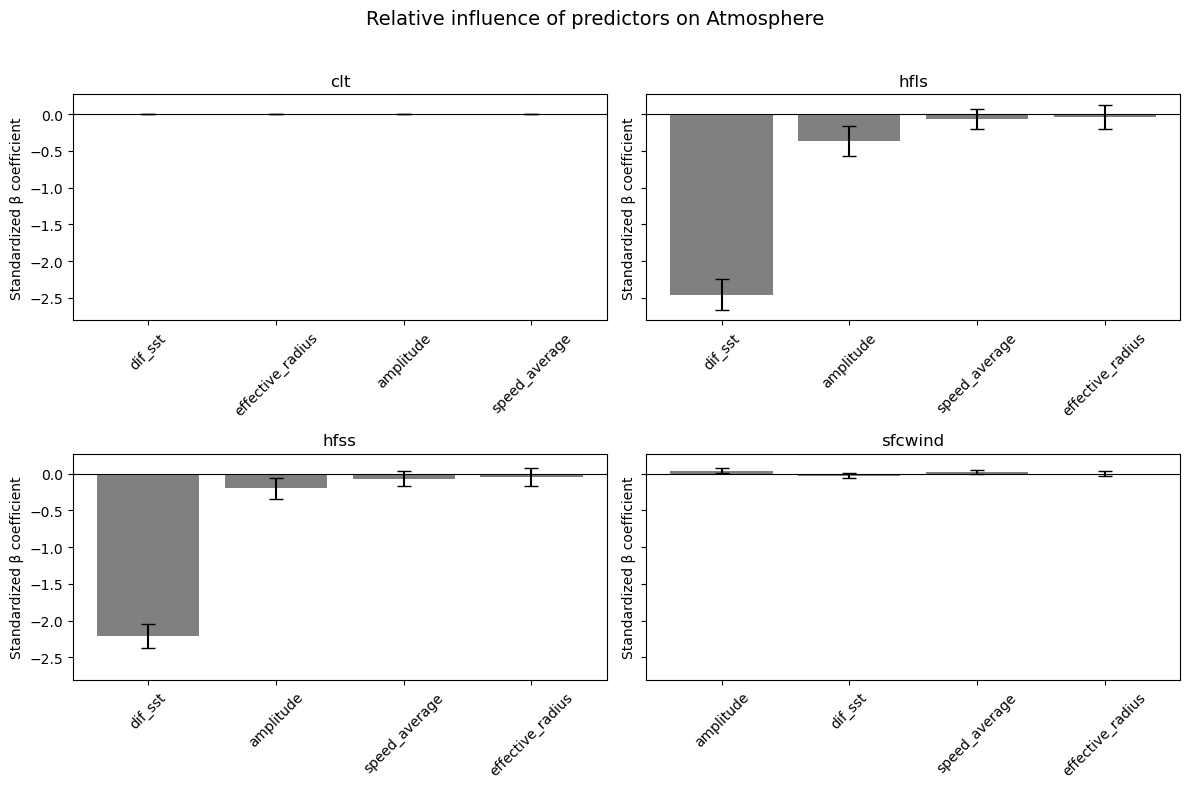

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.flatten()

params = [
    ("clt", sorted_predictors, sorted_mean, sorted_std),
    ("hfls", sorted_predictors_hfls, sorted_mean_hfls, sorted_std_hfls),
    ("hfss", sorted_predictors_hfss, sorted_mean_hfss, sorted_std_hfss),
    ("sfcwind", sorted_predictors_sfcwind, sorted_mean_sfcwind, sorted_std_sfcwind),
]

for ax, (title, predictors, mean, std) in zip(axes, params):
    ax.bar(predictors, mean, yerr=std, capsize=5, color="grey")
    ax.axhline(0, color="k", linewidth=0.8)
    ax.set_title(title)
    ax.set_ylabel("Standardized β coefficient")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Relative influence of predictors on Atmosphere", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("clt_eddy_obs_multreg_4panel.pdf")
plt.show()


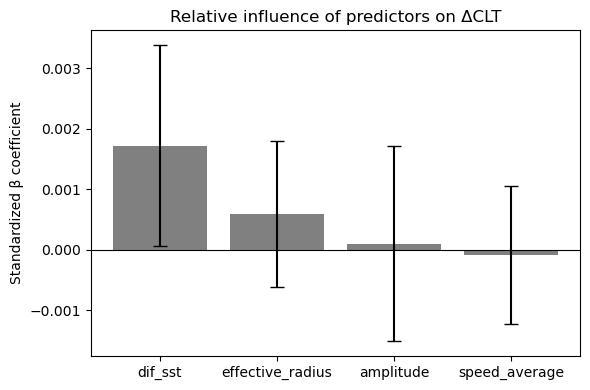

In [14]:
# Plot
plt.figure(figsize=(6, 4))
plt.bar(sorted_predictors, sorted_mean, yerr=sorted_std, capsize=5, color='grey')
plt.ylabel('Standardized β coefficient')
plt.title('Relative influence of predictors on ΔCLT')
plt.axhline(0, color='k', linewidth=0.8)
plt.tight_layout()
plt.savefig("clt_eddy_obs_multreg.pdf")
plt.show()a


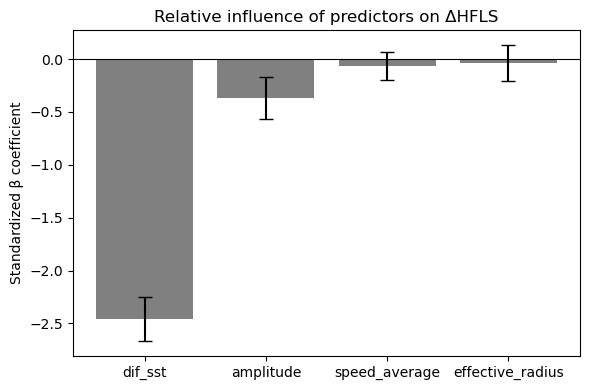

In [16]:
# Plot
plt.figure(figsize=(6, 4))
plt.bar(sorted_predictors_hfls, sorted_mean_hfls, yerr=sorted_std_hfls, capsize=5, color='grey')
plt.ylabel('Standardized β coefficient')
plt.title('Relative influence of predictors on ΔHFLS')
plt.axhline(0, color='k', linewidth=0.8)
plt.tight_layout()
plt.savefig("hfls_eddy_obs_multreg.pdf")
plt.show()


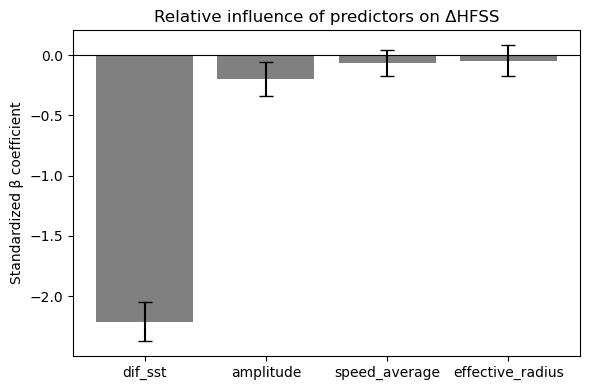

In [17]:
# Plot
plt.figure(figsize=(6, 4))
plt.bar(sorted_predictors_hfss, sorted_mean_hfss, yerr=sorted_std_hfss, capsize=5, color='grey')
plt.ylabel('Standardized β coefficient')
plt.title('Relative influence of predictors on ΔHFSS')
plt.axhline(0, color='k', linewidth=0.8)
plt.tight_layout()
plt.savefig("hfss_eddy_obs_multreg.pdf")
plt.show()


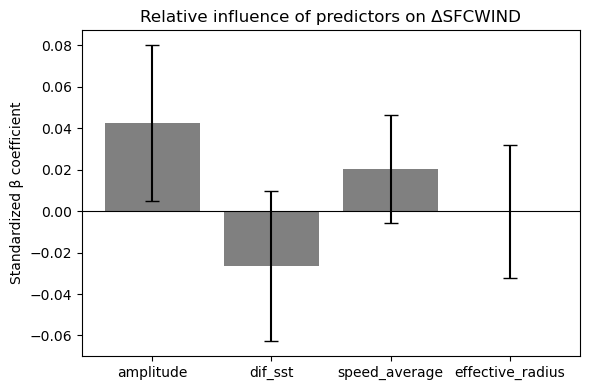

In [18]:
# Plot
plt.figure(figsize=(6, 4))
plt.bar(sorted_predictors_sfcwind, sorted_mean_sfcwind, yerr=sorted_std_sfcwind, capsize=5, color='grey')
plt.ylabel('Standardized β coefficient')
plt.title('Relative influence of predictors on ΔSFCWIND')
plt.axhline(0, color='k', linewidth=0.8)
plt.tight_layout()
plt.savefig("sfcwind_eddy_obs_multreg.pdf")
plt.show()


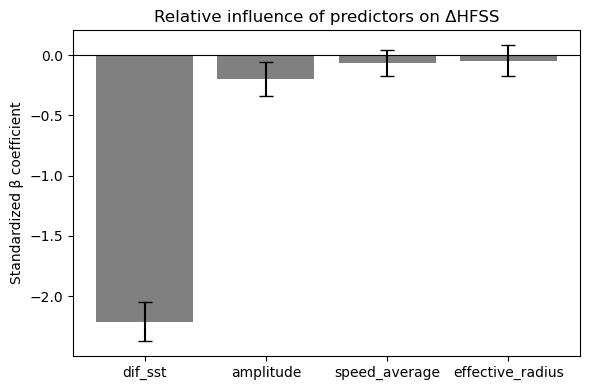

In [19]:
# Plot
plt.figure(figsize=(6, 4))
plt.bar(sorted_predictors_hfss, sorted_mean_hfss, yerr=sorted_std_hfss, capsize=5, color='grey')
plt.ylabel('Standardized β coefficient')
plt.title('Relative influence of predictors on ΔHFSS')
plt.axhline(0, color='k', linewidth=0.8)
plt.tight_layout()
plt.savefig("hfss_eddy_obs_multreg.pdf")
plt.show()


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif["variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)

In [37]:
ols = sm.OLS(y_std, X_std).fit()


In [38]:
resid = ols.resid


In [39]:
df_pd_sorted = df_pd.sort_values("time")
resid_sorted = resid[df_pd_sorted.index]


In [40]:
import numpy as np

rho_t = np.corrcoef(resid_sorted[:-1], resid_sorted[1:])[0, 1]
print("Lag-1 autocorrelation:", rho_t)


Lag-1 autocorrelation: -0.0076316300385780265


In [48]:
clt = da_atmos_so["clt"].values
# clt is (lat, lon, time)
clt_ts = clt.mean(axis=(0,1))   # now shape = (time,)


In [49]:
rho_t = np.corrcoef(clt_ts[:-1], clt_ts[1:])[0, 1]
print("Lag-1 autocorrelation:", rho_t)


Lag-1 autocorrelation: 0.9998948402550756


In [47]:
import numpy as np

rho_t = np.corrcoef(clt[:-1], clt[1:])[0, 1]
print("Lag-1 autocorrelation of CLT:", rho_t)


ValueError: m has more than 2 dimensions